<a href="https://colab.research.google.com/github/tifli/142a-project/blob/main/IOER_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Import Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split, cross_val_score, KFold, LeaveOneOut
from sklearn.linear_model import LinearRegression

In [2]:
K_FOLDS = 5
RANDOM_STATE = 42
TEST_SIZE = 0.2

##Import Dataset

In [3]:
from sklearn.preprocessing import StandardScaler

url = "https://raw.githubusercontent.com/tifli/142a-project/refs/heads/main/university_ranking.csv"
df = pd.read_csv(url)
df = df[df['year'] >= 2016]

# List of columns that should be numeric but might contain commas or percent signs
cols_to_clean = ['No. of FTE students', 'No. of students per staff',
                 'International students', 'International Outlook', 'Industry']

for col in cols_to_clean:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '').str.replace('%', '').str.replace('-', ''), errors='coerce')

TARGET = 'Rank'

X = df.drop(['Female:Male ratio', 'rank_prefix', TARGET], axis=1)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

# One-hot encode categorical variables for machine learning models
X_train_encoded = pd.get_dummies(X_train, drop_first=True, dtype=float)
X_test_encoded = pd.get_dummies(X_test, drop_first=True, dtype=float)

# Align columns to ensure test set has the exact same dummy features as train set
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0.0)

scaler = StandardScaler()

# Scale the encoded datasets and maintain DataFrame structure
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_encoded), columns=X_train_encoded.columns, index=X_train_encoded.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_encoded), columns=X_test_encoded.columns, index=X_test_encoded.index)

# Construct train_data using the ORIGINAL X_train for OLS
train_data = pd.concat([X_train, y_train], axis=1)

##Linear Regression

####Without "Name" column

In [4]:
ols = smf.ols(formula='Rank ~ Q("No. of FTE students") + Q("No. of students per staff") + Q("International students") + Overall + Industry + Teaching + Q("Research Environment") + Q("Research Quality") + Q("International Outlook")',
                 data=train_data)
model_lr = ols.fit()
print(model_lr.summary())

y_pred = model_lr.predict(X_test_scaled)
SSE = np.sum((y_test - y_pred)**2)
SST = np.sum((y_test - np.mean(y_train))**2)
osr_reduced = 1 - SSE/SST

print()
print(f"OSR-squared (reduced model): {osr_reduced}")

                            OLS Regression Results                            
Dep. Variable:                   Rank   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.854
Method:                 Least Squares   F-statistic:                     1103.
Date:                Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                        08:15:46   Log-Likelihood:                -7654.3
No. Observations:                1696   AIC:                         1.533e+04
Df Residuals:                    1686   BIC:                         1.538e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

####With "Name" column

*Use one-hot encoding*

In [5]:
CAT_VAR = 'Name'
features = [col for col in train_data.columns if col != TARGET]

X_train_scaled_const = sm.add_constant(X_train_scaled)

dependent_var = train_data[TARGET]
model_encode = sm.OLS(dependent_var, X_train_scaled_const).fit()

# Print the first 30 lines of the summary using str()
summary_str = str(model_encode.summary())
print('\n'.join(summary_str.split('\n')[:30]))

X_test_scaled_const = sm.add_constant(X_test_scaled, has_constant='add')
y_pred = model_encode.predict(X_test_scaled_const)

SSE = np.sum((y_test - y_pred)**2)
SST = np.sum((y_test - np.mean(y_train))**2)
osr_full = 1 - SSE/SST
print()
print(f"OSR-squared (full model): {osr_full}")

                            OLS Regression Results                            
Dep. Variable:                   Rank   R-squared:                       0.979
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                     254.7
Date:                Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                        08:15:47   Log-Likelihood:                -6001.1
No. Observations:                1696   AIC:                         1.254e+04
Df Residuals:                    1429   BIC:                         1.399e+04
Df Model:                         266                                         
Covariance Type:            nonrobust                                         
                                                                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

**Summary**

Note that both the R-squared and OSR-squared values for the full model above (with "Name") are higher than the reduced model (without "Name"). Hence, we should keep the universities' names in the final model for more accurate predictions.

## Ridge Regression

In [6]:
from sklearn.linear_model import LassoCV, RidgeCV

loocv = LeaveOneOut()
ridge_cv = RidgeCV(cv=loocv, scoring='neg_mean_squared_error').fit(X_train_scaled, y_train)

print(f"Best lambda: {ridge_cv.alpha_}")

y_pred_l2 = ridge_cv.predict(X_test_scaled)
SSE = np.sum((y_test - y_pred_l2)**2)
SST = np.sum((y_test - np.mean(y_train))**2)
OSR2_l2 = 1 - (SSE/SST)

print(f"OSR2 = {OSR2_l2}")

print("\nFirst 20 Regression coefficients:")
ridge_coefs = pd.Series(ridge_cv.coef_, index=X_train_encoded.columns)
print(ridge_coefs.head(20))

Best lambda: 0.1
OSR2 = 0.9693252730685784

First 20 Regression coefficients:
year                                      10.217520
No. of FTE students                        0.240416
No. of students per staff                 -1.007514
International students                    -7.835258
Overall                                  116.443637
Teaching                                 -78.010099
Research Environment                     -95.825371
Research Quality                         -60.233293
Industry                                  -5.810154
International Outlook                    -14.459787
Name_Aarhus University                    -2.866460
Name_Abu Dhabi University                  1.028907
Name_Adelaide University                  -0.848310
Name_Arizona State University (Tempe)     -0.284554
Name_Australian National University       -0.986327
Name_Beijing Normal University            -0.523424
Name_Bielefeld University                 -0.049710
Name_Boston University                

,Feature,OLS,Ridge
0,year,9.852779,10.217520
1,No. of FTE students,0.522753,0.240416
2,No. of students per staff,-0.414251,-1.007514
3,International students,-7.729593,-7.835258
4,Overall,190.731971,116.443637
5,Teaching,-111.098082,-78.010099
6,Research Environment,-130.866944,-95.825371
7,Research Quality,-83.873168,-60.233293
8,Industry,-10.630024,-5.810154
9,International Outlook,-23.267127,-14.459787


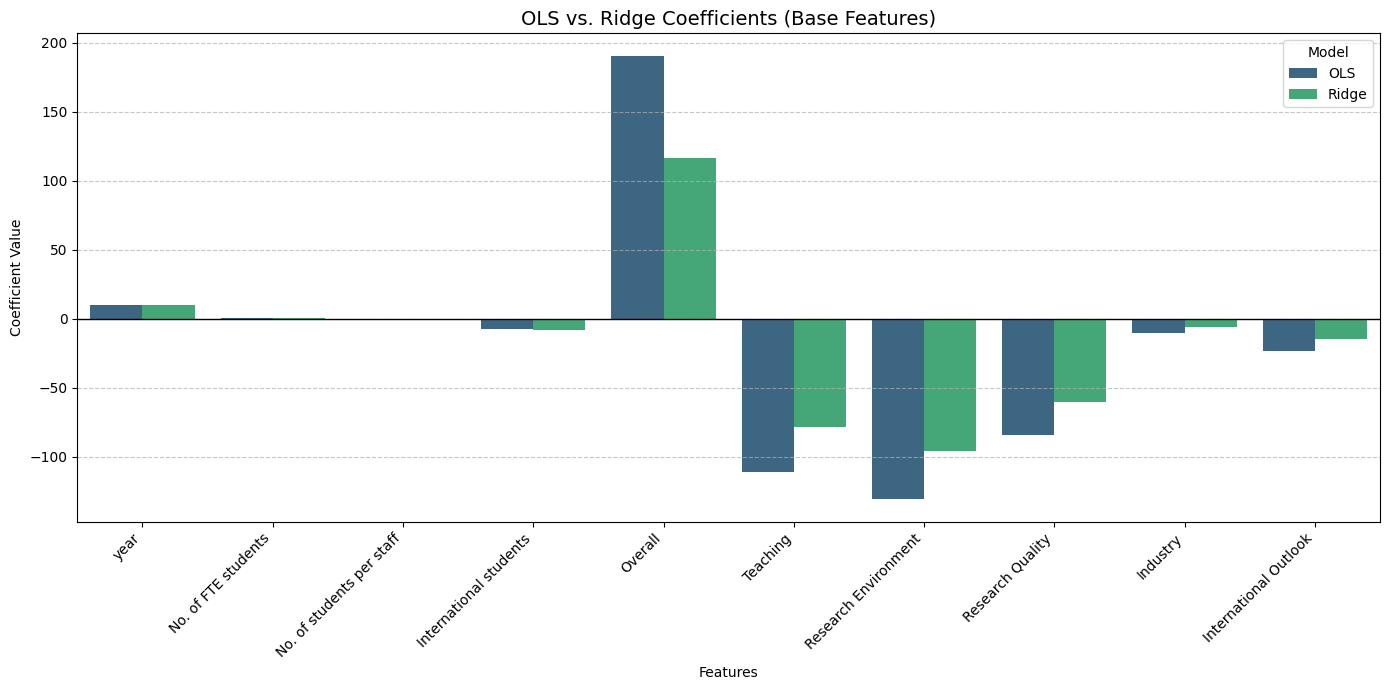

In [7]:
# Fit standard OLS on the scaled data for a fair comparison with Ridge
from sklearn.linear_model import LinearRegression

ols_scaled = LinearRegression().fit(X_train_scaled, y_train)

# Create a DataFrame with the features and their corresponding coefficients
coef_df = pd.DataFrame({
    'Feature': X_train_encoded.columns,
    'OLS': ols_scaled.coef_,
    'Ridge': ridge_cv.coef_
})

# Display the top coefficients table (to avoid a massive table)
display(coef_df.head(15))

# To keep the plot readable, filter down to just the original numeric features
numeric_cols = [c for c in X_train_encoded.columns if not c.startswith('Name_')]
coef_df_numeric = coef_df[coef_df['Feature'].isin(numeric_cols)]

# Melt the DataFrame to make it compatible with Seaborn's hue parameter
coef_df_melted = coef_df_numeric.melt(id_vars='Feature', var_name='Model', value_name='Coefficient')

# Plotting
plt.figure(figsize=(14, 7))
sns.barplot(data=coef_df_melted, x='Feature', y='Coefficient', hue='Model', palette='viridis')
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.title('OLS vs. Ridge Coefficients (Base Features)', fontsize=14)
plt.ylabel('Coefficient Value')
plt.xlabel('Features')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Model')
plt.tight_layout()
plt.show()

**Note**

Since none of the regression coefficients are close to zero, all of the features are important for the model. Thus, we must use PCA to combine features that are highly correlated with each. In this case, they are most likely 'Overall', 'Research Environment', and (possibly) 'Teaching'.

## CatBoost

In [8]:
import sys
!{sys.executable} -m pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.9 MB/s eta 0:00:00


In [26]:
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV

cb = CatBoostRegressor(verbose=0)

# Cross-validation
param_grid = {'iterations': [100, 300, 500],
              'learning_rate': [0.01, 0.03, 0.05],
              'depth': [4, 6, 8]}
grid_search = GridSearchCV(cb, param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)

# Specifying only 'Name' as the categorical feature
cat_features = ['Name']
grid_search.fit(X_train, y_train, cat_features=cat_features)

print(grid_search.best_params_)
cb_best = grid_search.best_estimator_

{'depth': 6, 'iterations': 500, 'learning_rate': 0.05}


In [27]:
y_train_pred_catboost = cb_best.predict(X_train)
y_test_pred_catboost = cb_best.predict(X_test)

print("=== CatBoost ===")
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred_catboost)))
print("Test RMSE :", np.sqrt(mean_squared_error(y_test, y_test_pred_catboost)))

=== CatBoost ===
Train RMSE: 1.5256307234314646
Test RMSE : 2.3116451705332044


In [28]:
# Feature Importances
importances_cb = cb_best.get_feature_importance()
sorted_idx = np.argsort(importances_cb)[::-1]
for i in sorted_idx:
  print(f"{X_train.columns[i]}: {importances_cb[i]:.4f}")

Overall: 63.5153
year: 20.7247
Research Environment: 7.8245
Teaching: 3.2879
Research Quality: 2.1931
Industry: 1.0763
No. of students per staff: 0.4521
International Outlook: 0.3902
No. of FTE students: 0.2708
International students: 0.1825
Name: 0.0827


##PCA

In [34]:
from sklearn.decomposition import PCA

# Use the one-hot encoded dataset to include categorical variables
X_train_pca_input = X_train_encoded

# Candidate numbers of principal components
max_components = min(X_train_pca_input.shape[1], 300)
component_grid = list(range(1, max_components + 1, 5))

# K-fold CV object (Use KFold instead of StratifiedKFold for continuous targets)
kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_scores = {}

for k in component_grid:
    fold_R_sq = []

    for train_idx, val_idx in kf.split(X_train_pca_input):
        # Split the training data into one training fold and one validation fold
        X_tr = X_train_pca_input.iloc[train_idx]
        X_val = X_train_pca_input.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        # Fit PCA only on the training fold
        pca = PCA(n_components=k)
        X_tr_pca = pca.fit_transform(X_tr)
        X_val_pca = pca.transform(X_val)

        # Fit linear regression on the PCA-transformed training fold
        lr = LinearRegression()
        lr.fit(X_tr_pca, y_tr)

        # Predict on the validation fold
        R = lr.score(X_val_pca, y_val)
        fold_R_sq.append(R)

    # Store the mean CV R-squared for this k
    cv_scores[k] = np.mean(fold_R_sq)
    print(f"k = {k:2d}, mean = {cv_scores[k]:.4f}")

k =  1, mean = -0.0009
k =  6, mean = 0.8358
k = 11, mean = 0.8654
k = 16, mean = 0.8656
k = 21, mean = 0.8660
k = 26, mean = 0.8668
k = 31, mean = 0.8672
k = 36, mean = 0.8701
k = 41, mean = 0.8697
k = 46, mean = 0.8698
k = 51, mean = 0.8727
k = 56, mean = 0.8748
k = 61, mean = 0.8745
k = 66, mean = 0.8788
k = 71, mean = 0.8791
k = 76, mean = 0.8780
k = 81, mean = 0.8811
k = 86, mean = 0.8833
k = 91, mean = 0.8847
k = 96, mean = 0.8856
k = 101, mean = 0.8914
k = 106, mean = 0.8916
k = 111, mean = 0.8983
k = 116, mean = 0.8925
k = 121, mean = 0.8986
k = 126, mean = 0.9001
k = 131, mean = 0.9037
k = 136, mean = 0.9055
k = 141, mean = 0.9058
k = 146, mean = 0.9121
k = 151, mean = 0.9122
k = 156, mean = 0.9145
k = 161, mean = 0.9168
k = 166, mean = 0.9219
k = 171, mean = 0.9241
k = 176, mean = 0.9234
k = 181, mean = 0.9288
k = 186, mean = 0.9354
k = 191, mean = 0.9373
k = 196, mean = 0.9425
k = 201, mean = 0.9438
k = 206, mean = 0.9476
k = 211, mean = 0.9515
k = 216, mean = 0.9547
k = 221

In [35]:
# Choose the best number of components
best_k = max(cv_scores, key=cv_scores.get)
print("\nBest number of principal components:", best_k)
print("Best mean CV R-squared:", cv_scores[best_k])


Best number of principal components: 266
Best mean CV R-squared: 0.96876956862494


In [36]:
# Refit on the full training set using best_k
pca_best = PCA(n_components=best_k)
X_train_pca_best = pca_best.fit_transform(X_train_encoded)
X_test_pca_best = pca_best.transform(X_test_encoded)

lr_best = LinearRegression()
lr_best.fit(X_train_pca_best, y_train)

train_R_sq = lr_best.score(X_train_pca_best, y_train)
test_R_sq = lr_best.score(X_test_pca_best, y_test)

print("\nFinal model results")
print("Train R-squared:", round(train_R_sq, 4))
print("Test R-squared :", round(test_R_sq, 4))


Final model results
Train R-squared: 0.9793
Test R-squared : 0.9692


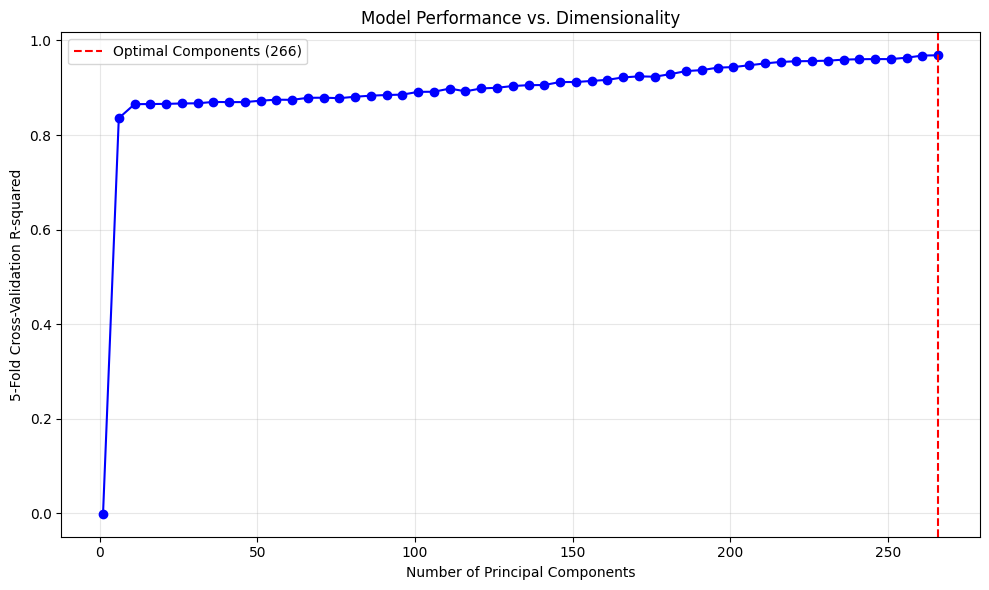

In [37]:
# --- VISUALIZATION: Cross-Validation R-squared Curve ---
mean_test_scores = [cv_scores[k] for k in component_grid]

plt.figure(figsize=(10, 6))
plt.plot(component_grid, mean_test_scores, marker='o', linestyle='-', color='b')
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Optimal Components ({best_k})')
plt.xlabel('Number of Principal Components')
plt.ylabel(f'5-Fold Cross-Validation R-squared')
plt.title('Model Performance vs. Dimensionality')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()